# Time-Domain Pitch Shifter

A two-head circular-buffer pitch shifter shifts pitch without changing duration.
Two Hann-windowed read heads traverse a delay buffer at pitch ratio
`r = 2^(semitones/12)`; their grain pointers are staggered by half the
buffer length so the windows always sum to 1 (partition of unity),
giving seamless crossfades at every grain boundary.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.delay import pitch_shift

FS = 44100

# Buffer size (must match implementation)
B = 1
while B < int(FS * 0.05):
    B <<= 1

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Hann Partition of Unity

The two heads carry Hann envelopes staggered by `B/2`.  Their sum is
exactly 1 everywhere — verified below.

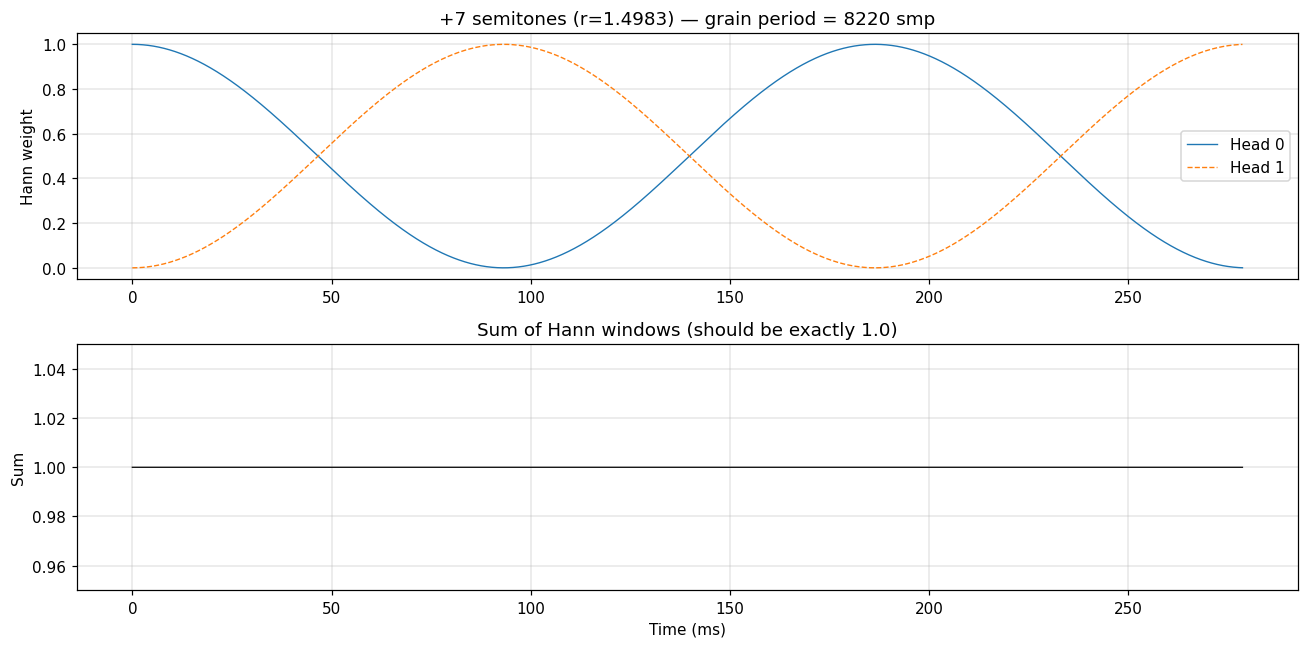

In [2]:
n_disp = np.arange(3 * B, dtype=float)
r_7up = 2 ** (7 / 12)

p0 = (B / 2.0 + (1 - r_7up) * n_disp) % B
p1 = (p0 + B / 2.0) % B
win0 = 0.5 * (1 - np.cos(2 * np.pi * p0 / B))
win1 = 0.5 * (1 - np.cos(2 * np.pi * p1 / B))

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
t_ms = n_disp / FS * 1000

ax = axes[0]
ax.plot(t_ms, win0, label='Head 0', linewidth=0.9)
ax.plot(t_ms, win1, label='Head 1', linestyle='--', linewidth=0.9)
ax.set_ylabel('Hann weight')
ax.set_title(f'+7 semitones (r={r_7up:.4f}) — grain period = {B / (r_7up - 1):.0f} smp')
ax.legend(); ax.grid(True, linewidth=0.3)

ax = axes[1]
ax.plot(t_ms, win0 + win1, color='black', linewidth=0.8)
ax.set_ylim(0.95, 1.05)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Sum')
ax.set_title('Sum of Hann windows (should be exactly 1.0)')
ax.grid(True, linewidth=0.3)
plt.tight_layout()

## Pitch Shift at Several Intervals

Shift a 440 Hz sine by −12, −7, −5, 0, +5, +7, and +12 semitones.

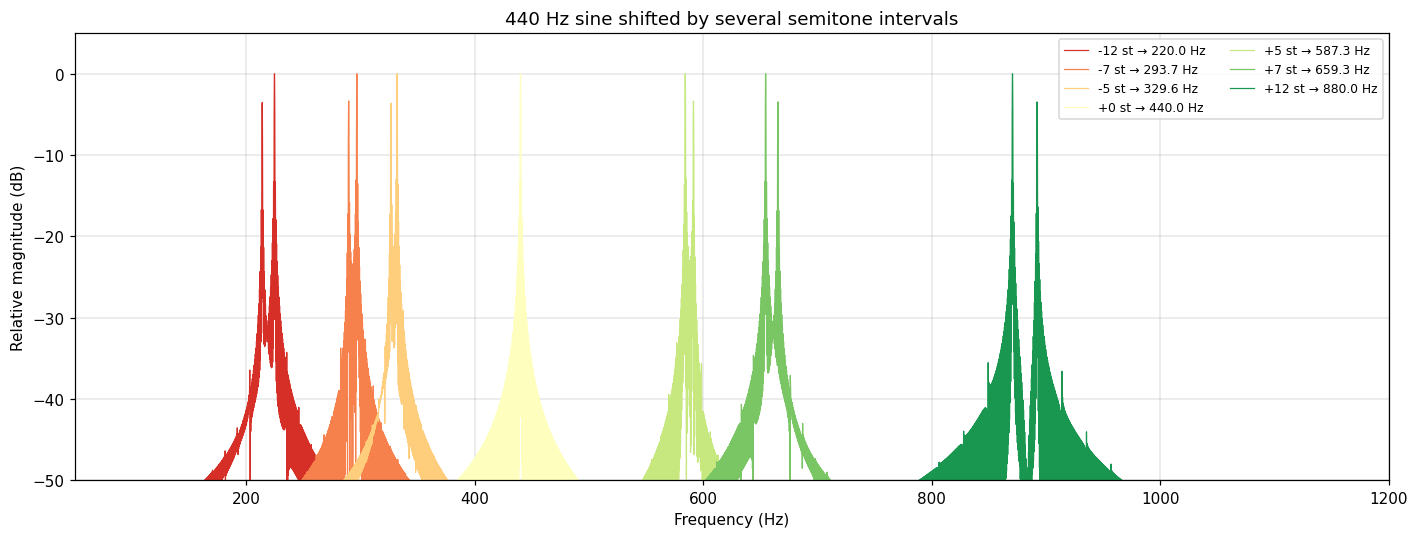

In [3]:
DURATION = 2.0
N = int(DURATION * FS)
t = np.arange(N) / FS
freq = 440.0
signal = np.sin(2 * np.pi * freq * t)

SEMITONES = [-12, -7, -5, 0, 5, 7, 12]
outputs = {s: pitch_shift(signal, FS, semitones=s) for s in SEMITONES}

# Steady-state region for FFT
steady = slice(B, N)
nfft = (N - B) * 8
freqs = np.fft.rfftfreq(nfft, 1.0 / FS)

fig, ax = plt.subplots(figsize=(13, 5))
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(SEMITONES)))

for i, s in enumerate(SEMITONES):
    spec = 20 * np.log10(np.abs(np.fft.rfft(outputs[s][steady], n=nfft)) + 1e-9)
    spec -= spec.max()
    expected = freq * 2 ** (s / 12)
    label = f'{s:+d} st → {expected:.1f} Hz'
    ax.plot(freqs, spec, color=colors[i], linewidth=0.8, label=label)

ax.set_xlim(50, 1200)
ax.set_ylim(-50, 5)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Relative magnitude (dB)')
ax.set_title('440 Hz sine shifted by several semitone intervals')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, linewidth=0.3)
plt.tight_layout()

## Passthrough Accuracy (semitones = 0)

For `semitones=0`, the grain pointer is constant and head 0 always reads
`B/2` samples behind the write head.  After the `B//2`-sample startup
latency, `out[B//2:]` must equal `signal[:N-B//2]` to floating-point precision.

In [4]:
out0 = outputs[0]
shift = B // 2
max_err = np.max(np.abs(out0[shift:] - signal[:N - shift]))
print(f'Max error after startup latency: {max_err:.2e}  (should be < 1e-12)')

Max error after startup latency: 0.00e+00  (should be < 1e-12)


## Pitch Accuracy via Zero-Crossing Period

Measure the pitch of each shifted output using the median inter-zero-crossing
period — robust to the amplitude modulation at grain boundaries.

In [5]:
def measure_pitch(signal, fs):
    crossings = np.where((signal[:-1] <= 0) & (signal[1:] > 0))[0]
    if len(crossings) < 2:
        return np.nan
    return fs / float(np.median(np.diff(crossings)))

print(f"{'Semitones':>10}  {'Expected Hz':>12}  {'Measured Hz':>12}  {'Error %':>8}")
print('-' * 50)
for s in SEMITONES:
    expected = freq * 2 ** (s / 12)
    measured = measure_pitch(outputs[s][B:], FS)
    err_pct = abs(measured - expected) / expected * 100
    print(f'{s:>+10d}  {expected:>12.2f}  {measured:>12.2f}  {err_pct:>7.2f}%')

 Semitones   Expected Hz   Measured Hz   Error %
--------------------------------------------------
       -12        220.00        221.61     0.73%
        -7        293.66        294.00     0.11%
        -5        329.63        331.58     0.59%
        +0        440.00        441.00     0.23%
        +5        587.33        588.00     0.11%
        +7        659.26        658.21     0.16%
       +12        880.00        882.00     0.23%


## Waveform Comparison — ±7 Semitones

The waveform of the pitch-shifted output is shown alongside the original,
after the startup latency.

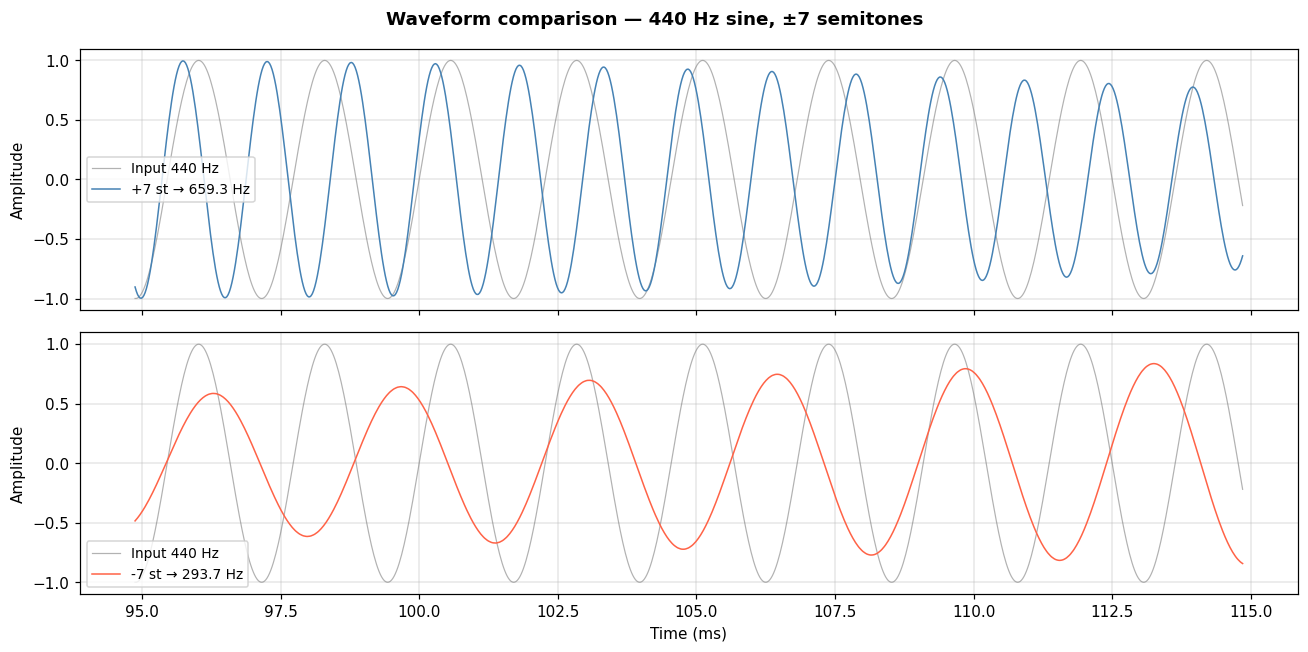

In [6]:
zoom_start = B + int(0.002 * FS)
zoom_end = zoom_start + int(0.020 * FS)
t_zoom_ms = t[zoom_start:zoom_end] * 1000

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax, (s, color) in zip(axes, [(7, 'steelblue'), (-7, 'tomato')]):
    exp = freq * 2 ** (s / 12)
    ax.plot(t_zoom_ms, signal[zoom_start:zoom_end],
            color='gray', linewidth=0.8, alpha=0.6, label=f'Input {freq:.0f} Hz')
    ax.plot(t_zoom_ms, outputs[s][zoom_start:zoom_end],
            color=color, linewidth=1.0, label=f'{s:+d} st → {exp:.1f} Hz')
    ax.set_ylabel('Amplitude')
    ax.legend(fontsize=9)
    ax.grid(True, linewidth=0.3)

axes[-1].set_xlabel('Time (ms)')
fig.suptitle('Waveform comparison — 440 Hz sine, ±7 semitones', fontweight='bold')
plt.tight_layout()

## Audio Playback

In [7]:
from IPython.display import Audio, display

print('Original 440 Hz')
display(Audio(signal, rate=FS))

print('+7 semitones (≈ 659 Hz)')
display(Audio(outputs[7], rate=FS))

print('−7 semitones (≈ 294 Hz)')
display(Audio(outputs[-7], rate=FS))

print('+12 semitones (880 Hz)')
display(Audio(outputs[12], rate=FS))

print('−12 semitones (220 Hz)')
display(Audio(outputs[-12], rate=FS))

Original 440 Hz


+7 semitones (≈ 659 Hz)


−7 semitones (≈ 294 Hz)


+12 semitones (880 Hz)


−12 semitones (220 Hz)
